In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving spotify dataset.csv to spotify dataset (1).csv


In [3]:
df = pd.read_csv("spotify dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [7]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (32833, 23)

Column Names:
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

Data Types:
track_id                     object
track_name                   object
track_artist                 object
track_popularity              int64
track_album_id               object
track_album_name             object
track_album_release_date     object
playlist_name                object
playlist_id                  object
playlist_genre               object
playlist_subgenre            object
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness       

In [8]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Series([], dtype: int64)


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (32833, 23)


In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully!")
print("Total missing values:", df.isnull().sum().sum())

Missing values handled successfully!
Total missing values: 0


In [16]:
df["duration_min"] = df["duration_ms"] / 60000

df[["track_name", "duration_ms", "duration_min"]].head()

,track_name,duration_ms,duration_min
0,I Don't Care (with Justin Bieber) - Loud Luxur...,194754,3.245900
1,Memories - Dillon Francis Remix,162600,2.710000
2,All the Time - Don Diablo Remix,176616,2.943600
3,Call You Mine - Keanu Silva Remix,169093,2.818217
4,Someone You Loved - Future Humans Remix,189052,3.150867


In [15]:
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [13]:
print("Number of Genres:", df["playlist_genre"].nunique())

print("\nGenre Distribution:")
print(df["playlist_genre"].value_counts())

Number of Genres: 6

Genre Distribution:
playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64


In [14]:
print("Number of Subgenres:", df["playlist_subgenre"].nunique())

print("\nTop 15 Subgenres:")
print(df["playlist_subgenre"].value_counts().head(15))

Number of Subgenres: 24

Top 15 Subgenres:
playlist_subgenre
progressive electro house    1809
southern hip hop             1675
indie poptimism              1672
latin hip hop                1656
neo soul                     1637
pop edm                      1517
electro house                1511
hard rock                    1485
gangster rap                 1458
electropop                   1408
urban contemporary           1405
hip hop                      1322
dance pop                    1298
classic rock                 1296
trap                         1291
Name: count, dtype: int64


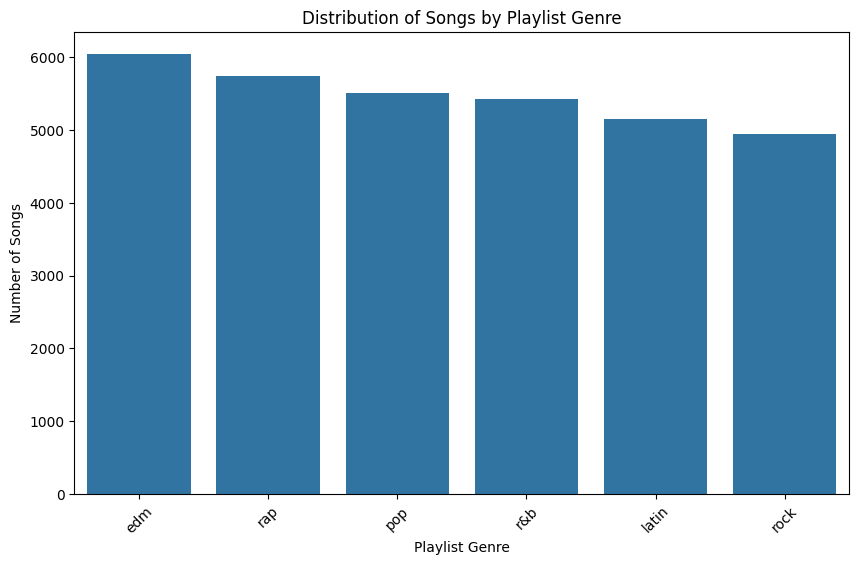

In [12]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="playlist_genre",
    order=df["playlist_genre"].value_counts().index
)

plt.title("Distribution of Songs by Playlist Genre")
plt.xlabel("Playlist Genre")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


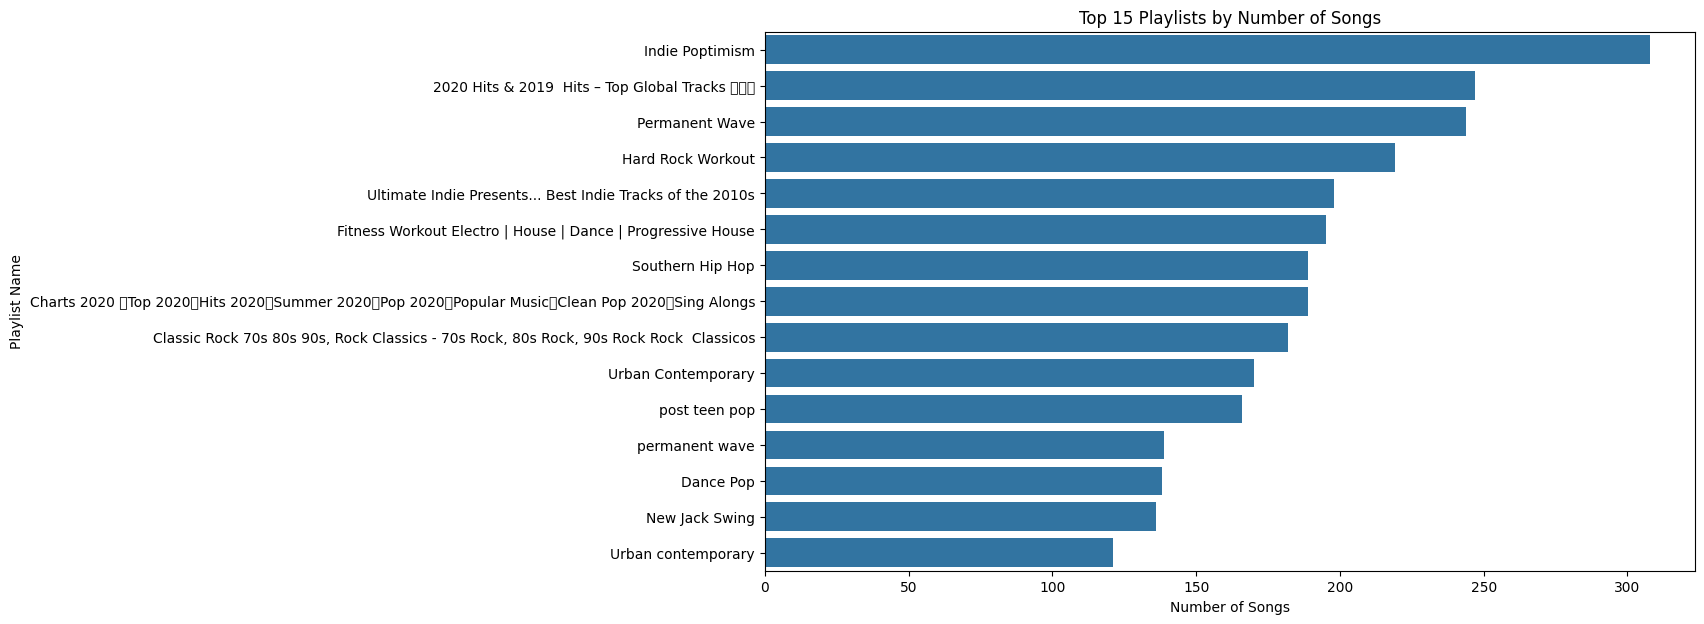

In [11]:
top_playlists = df["playlist_name"].value_counts().head(15)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top_playlists.values,
    y=top_playlists.index
)

plt.title("Top 15 Playlists by Number of Songs")
plt.xlabel("Number of Songs")
plt.ylabel("Playlist Name")
plt.show()

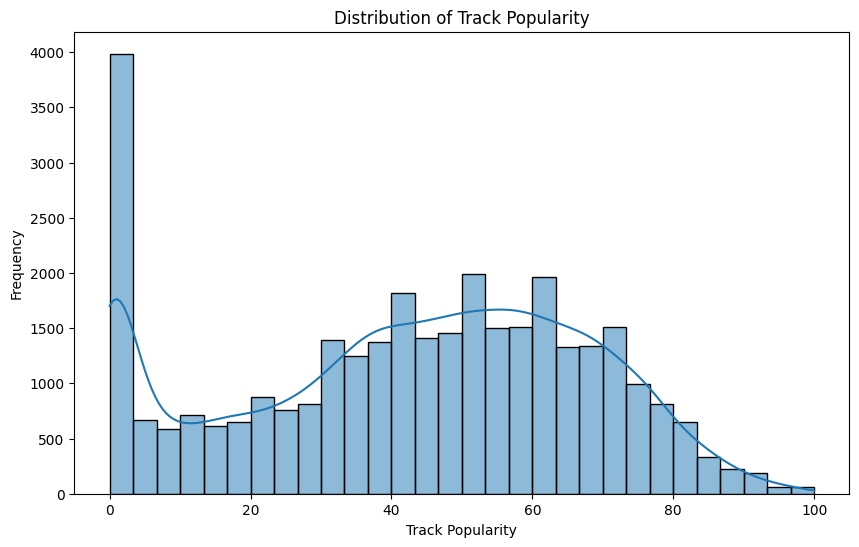

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["track_popularity"],
    bins=30,
    kde=True
)

plt.title("Distribution of Track Popularity")
plt.xlabel("Track Popularity")
plt.ylabel("Frequency")
plt.show()

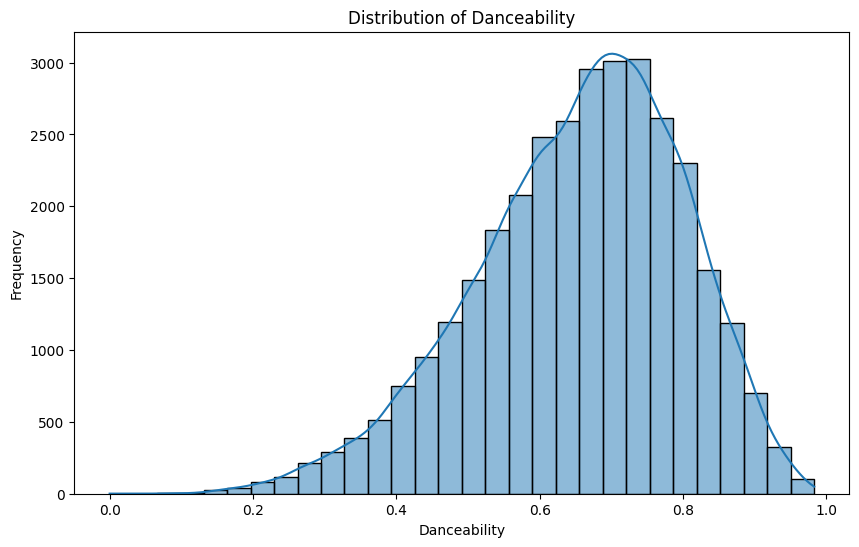

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["danceability"],
    bins=30,
    kde=True
)

plt.title("Distribution of Danceability")
plt.xlabel("Danceability")
plt.ylabel("Frequency")
plt.show()

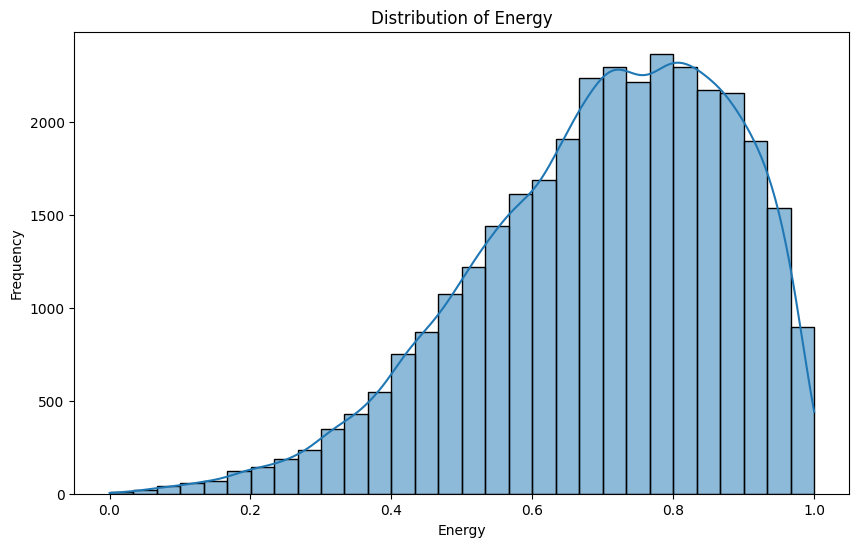

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["energy"],
    bins=30,
    kde=True
)

plt.title("Distribution of Energy")
plt.xlabel("Energy")
plt.ylabel("Frequency")
plt.show()

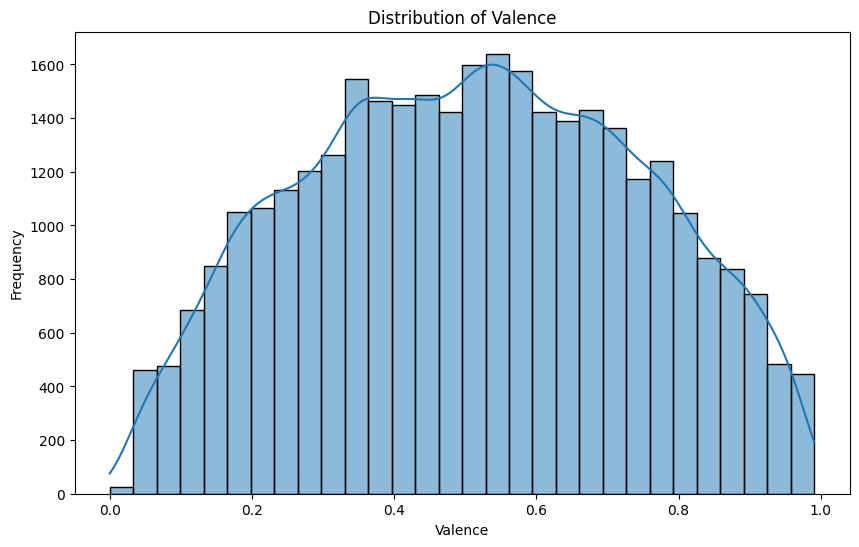

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["valence"],
    bins=30,
    kde=True
)

plt.title("Distribution of Valence")
plt.xlabel("Valence")
plt.ylabel("Frequency")
plt.show()

In [21]:
genre_features = df.groupby("playlist_genre")[
    ["danceability", "energy", "acousticness",
     "instrumentalness", "liveness", "valence"]
].mean()

genre_features

,danceability,energy,acousticness,instrumentalness,liveness,valence
playlist_genre,,,,,,
edm,0.655041,0.802476,0.081504,0.218578,0.211859,0.400656
latin,0.713287,0.708312,0.210920,0.044447,0.180626,0.605510
pop,0.639302,0.701028,0.170794,0.059876,0.176833,0.503521
r&b,0.670179,0.590934,0.259904,0.028920,0.175268,0.531231
rap,0.718353,0.650708,0.192479,0.075997,0.191654,0.505090
rock,0.520548,0.732813,0.145189,0.062417,0.203135,0.537352


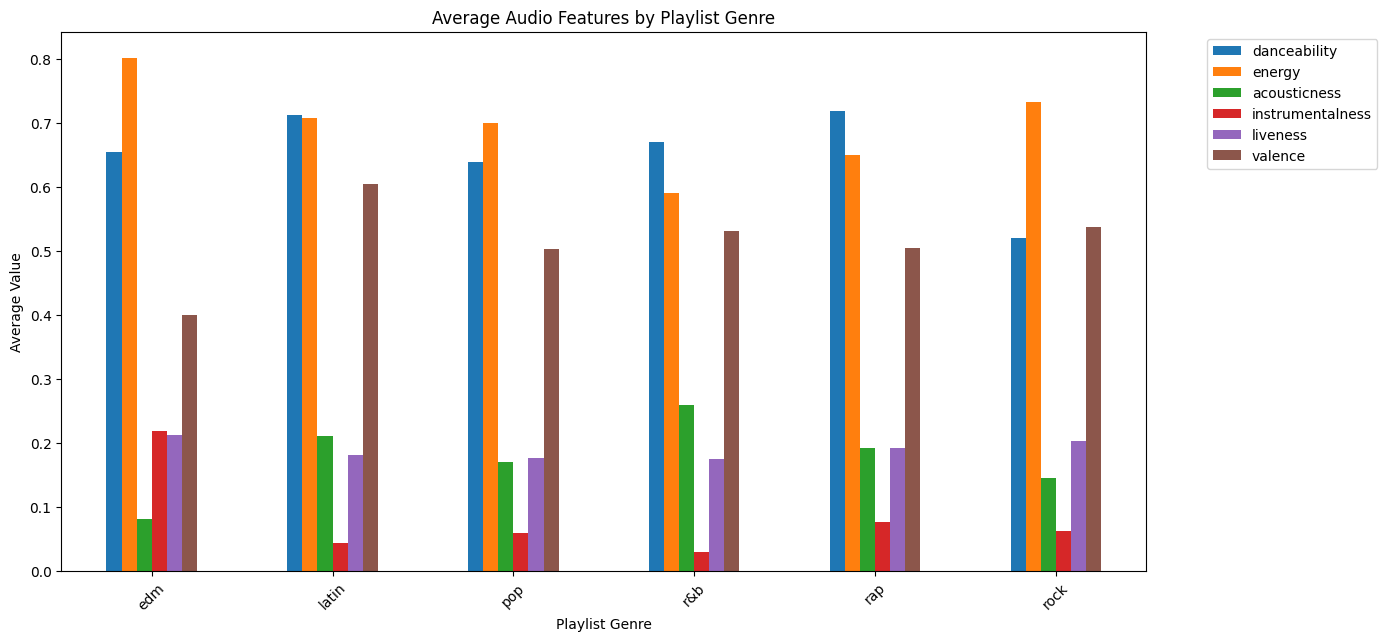

In [22]:
genre_features.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Average Audio Features by Playlist Genre")
plt.xlabel("Playlist Genre")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

In [23]:
correlation_cols = [
    "track_popularity",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min"
]

correlation_matrix = df[correlation_cols].corr()

correlation_matrix

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
track_popularity,1.000000,0.064748,-0.109112,-0.000650,0.057687,0.010637,0.006819,0.085159,-0.149872,-0.054584,0.033231,-0.005378,-0.143682
danceability,0.064748,1.000000,-0.086073,0.011736,0.025335,-0.058647,0.181721,-0.024519,-0.008655,-0.123859,0.330523,-0.184084,-0.096879
energy,-0.109112,-0.086073,1.000000,0.010052,0.676625,-0.004800,-0.032150,-0.539745,0.033247,0.161223,0.151103,0.149951,0.012611
key,-0.000650,0.011736,0.010052,1.000000,0.000959,-0.174093,0.022607,0.004306,0.005968,0.002887,0.019914,-0.013370,0.015139
loudness,0.057687,0.025335,0.676625,0.000959,1.000000,-0.019289,0.010339,-0.361638,-0.147824,0.077613,0.053384,0.093767,-0.115058
mode,0.010637,-0.058647,-0.004800,-0.174093,-0.019289,1.000000,-0.063512,0.009415,-0.006741,-0.005549,0.002614,0.014329,0.015634
speechiness,0.006819,0.181721,-0.032150,0.022607,0.010339,-0.063512,1.000000,0.026092,-0.103424,0.055426,0.064659,0.044603,-0.089431
acousticness,0.085159,-0.024519,-0.539745,0.004306,-0.361638,0.009415,0.026092,1.000000,-0.006850,-0.077243,-0.016845,-0.112724,-0.081581
instrumentalness,-0.149872,-0.008655,0.033247,0.005968,-0.147824,-0.006741,-0.103424,-0.006850,1.000000,-0.005507,-0.175402,0.023335,0.063235
liveness,-0.054584,-0.123859,0.161223,0.002887,0.077613,-0.005549,0.055426,-0.077243,-0.005507,1.000000,-0.020560,0.021018,0.006138


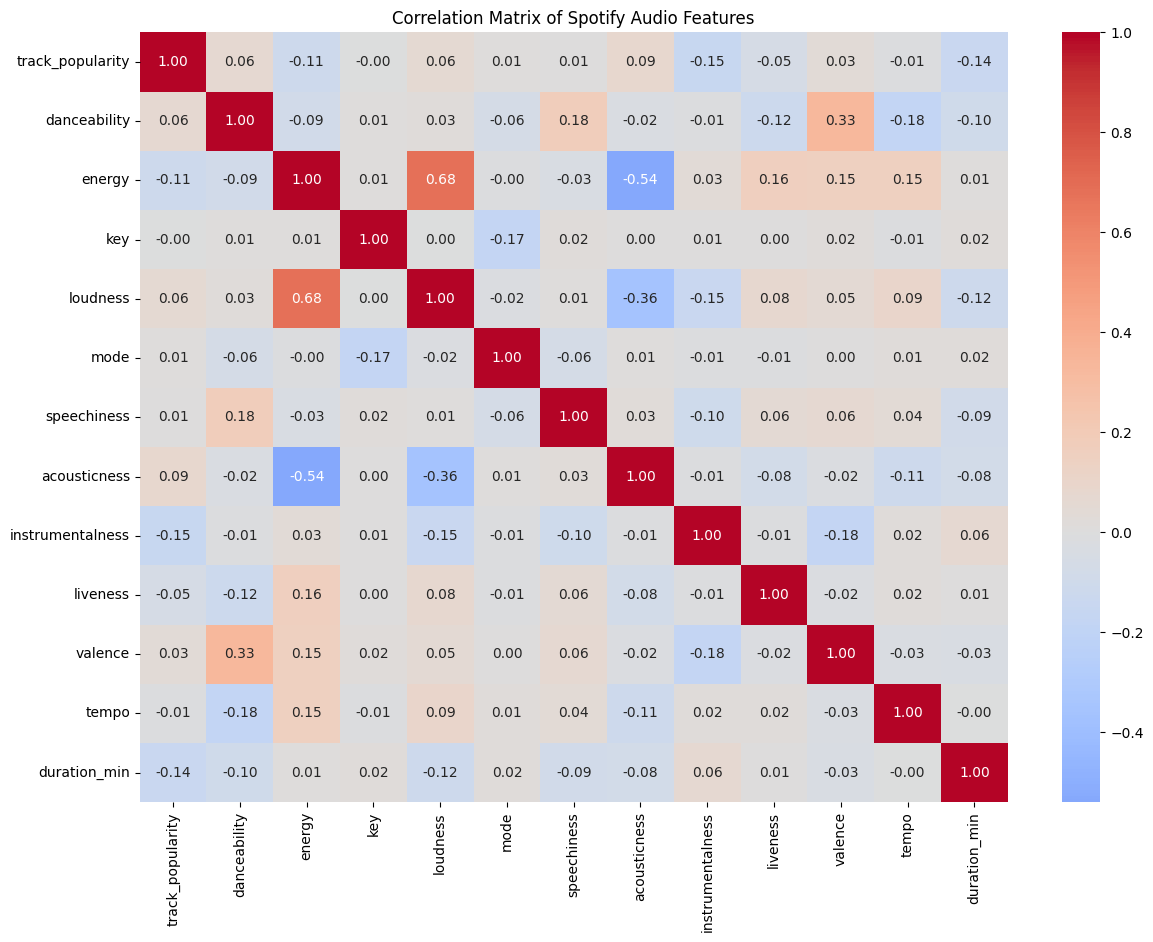

In [24]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Spotify Audio Features")
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [26]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

X = df[features].copy()

print("Features used for clustering:")
print(features)

print("\nShape:", X.shape)

Features used for clustering:
['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

Shape: (32833, 9)


In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed!")
print("Scaled data shape:", X_scaled.shape)

Feature scaling completed!
Scaled data shape: (32833, 9)


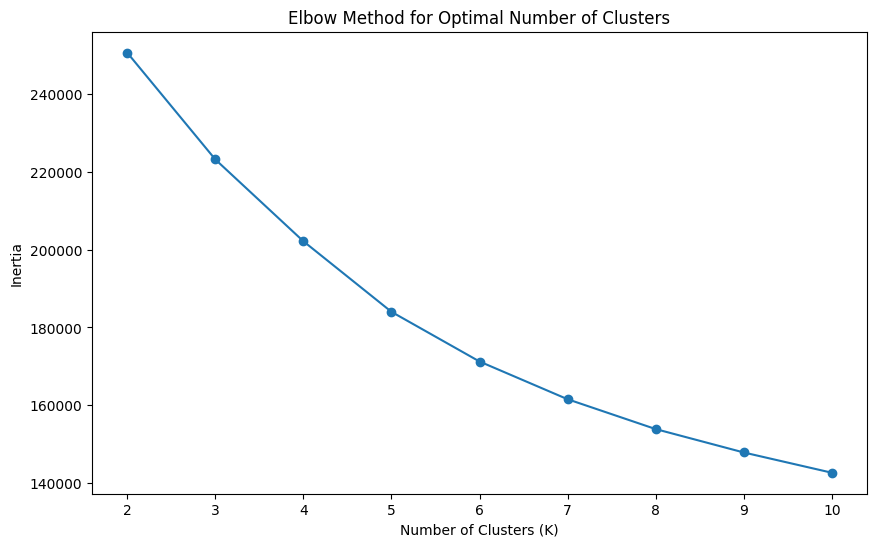

In [28]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,6))

plt.plot(K, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K)
plt.show()

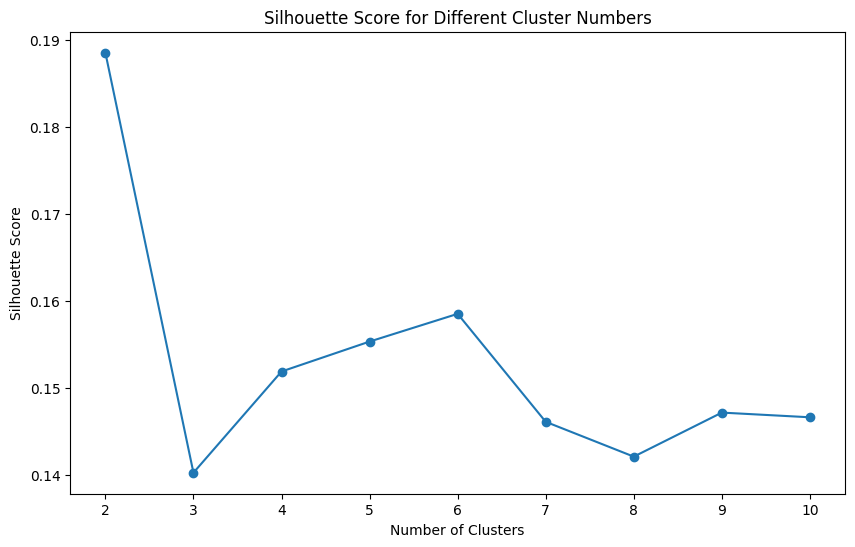

In [32]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10,6))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different Cluster Numbers")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2,11))
plt.show()

In [33]:
best_k = range(2, 11)[np.argmax(silhouette_scores)]

print("Best Number of Clusters:", best_k)

Best Number of Clusters: 2


In [34]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")
print("\nCluster Distribution:")
print(df["cluster"].value_counts().sort_index())

K-Means clustering completed!

Cluster Distribution:
cluster
0    23182
1     9651
Name: count, dtype: int64


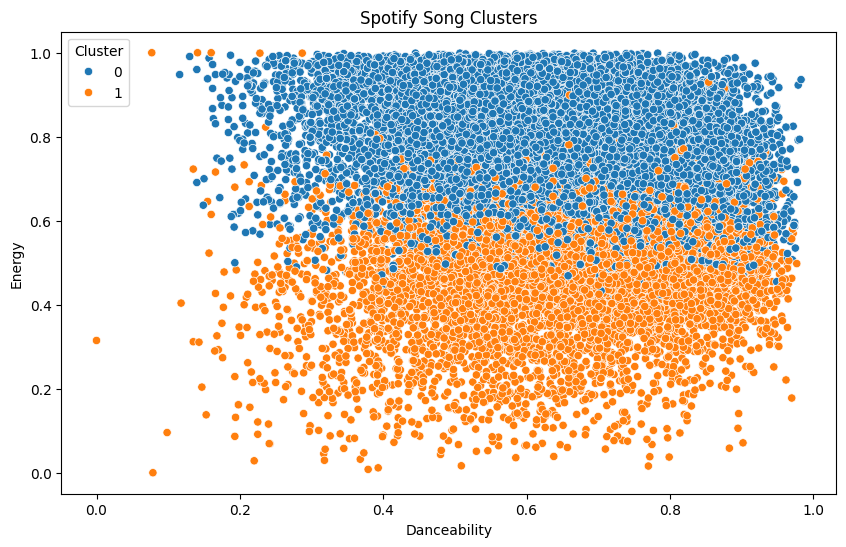

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="danceability",
    y="energy",
    hue="cluster",
    palette="tab10"
)

plt.title("Spotify Song Clusters")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.legend(title="Cluster")
plt.show()

In [36]:
cluster_profile = df.groupby("cluster")[features].mean()

cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.652856,0.784709,-5.482087,0.105038,0.093106,0.077474,0.204288,0.532376,123.963221
1,0.659637,0.491829,-9.691801,0.111943,0.372847,0.102218,0.156279,0.458161,113.477856


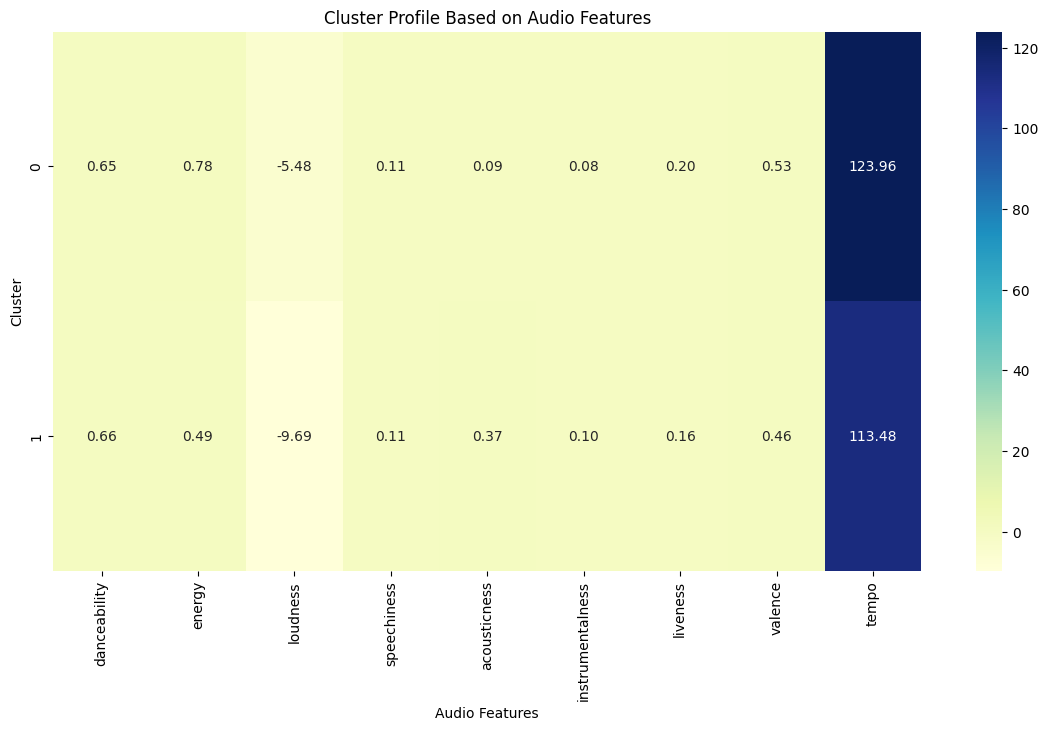

In [37]:
plt.figure(figsize=(14,7))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Cluster Profile Based on Audio Features")
plt.xlabel("Audio Features")
plt.ylabel("Cluster")

plt.show()

In [38]:
genre_cluster = pd.crosstab(
    df["playlist_genre"],
    df["cluster"]
)

genre_cluster

cluster,0,1
playlist_genre,,
edm,5384,659
latin,3853,1302
pop,4112,1395
r&b,2636,2795
rap,3727,2019
rock,3470,1481


<Figure size 1200x700 with 0 Axes>

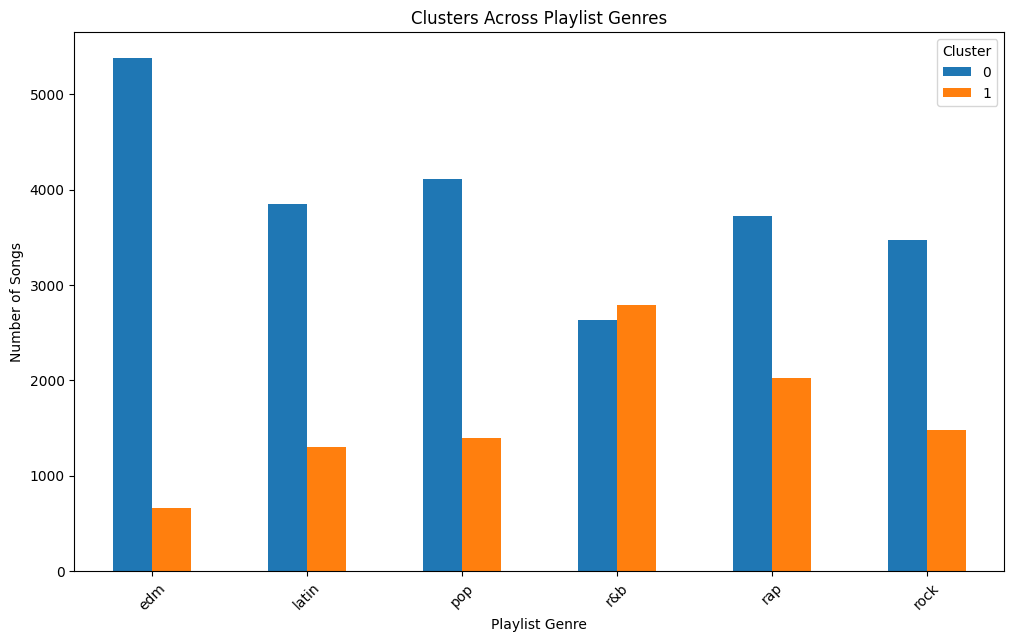

In [39]:
plt.figure(figsize=(12,7))

genre_cluster.plot(
    kind="bar",
    figsize=(12,7)
)

plt.title("Clusters Across Playlist Genres")
plt.xlabel("Playlist Genre")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.show()

In [40]:
playlist_cluster = pd.crosstab(
    df["playlist_name"],
    df["cluster"]
)

playlist_cluster.head(20)

cluster,0,1
playlist_name,,
"""Permanent Wave""",14,9
10er Playlist,48,13
1987-1997 OLD SKOOL JAMZ,31,10
2000's hard rock,45,0
2010 - 2011 - 2012 - 2013 - 2014 - 2015 - 2016 - 2017 - 2018 - 2019 - 2020 TOP HITS,65,18
2011-2014 House,95,1
2015 songs,77,14
2019 in Indie Poptimism,58,40
2020 Hits & 2019 Hits – Top Global Tracks 🔥🔥🔥,149,98


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


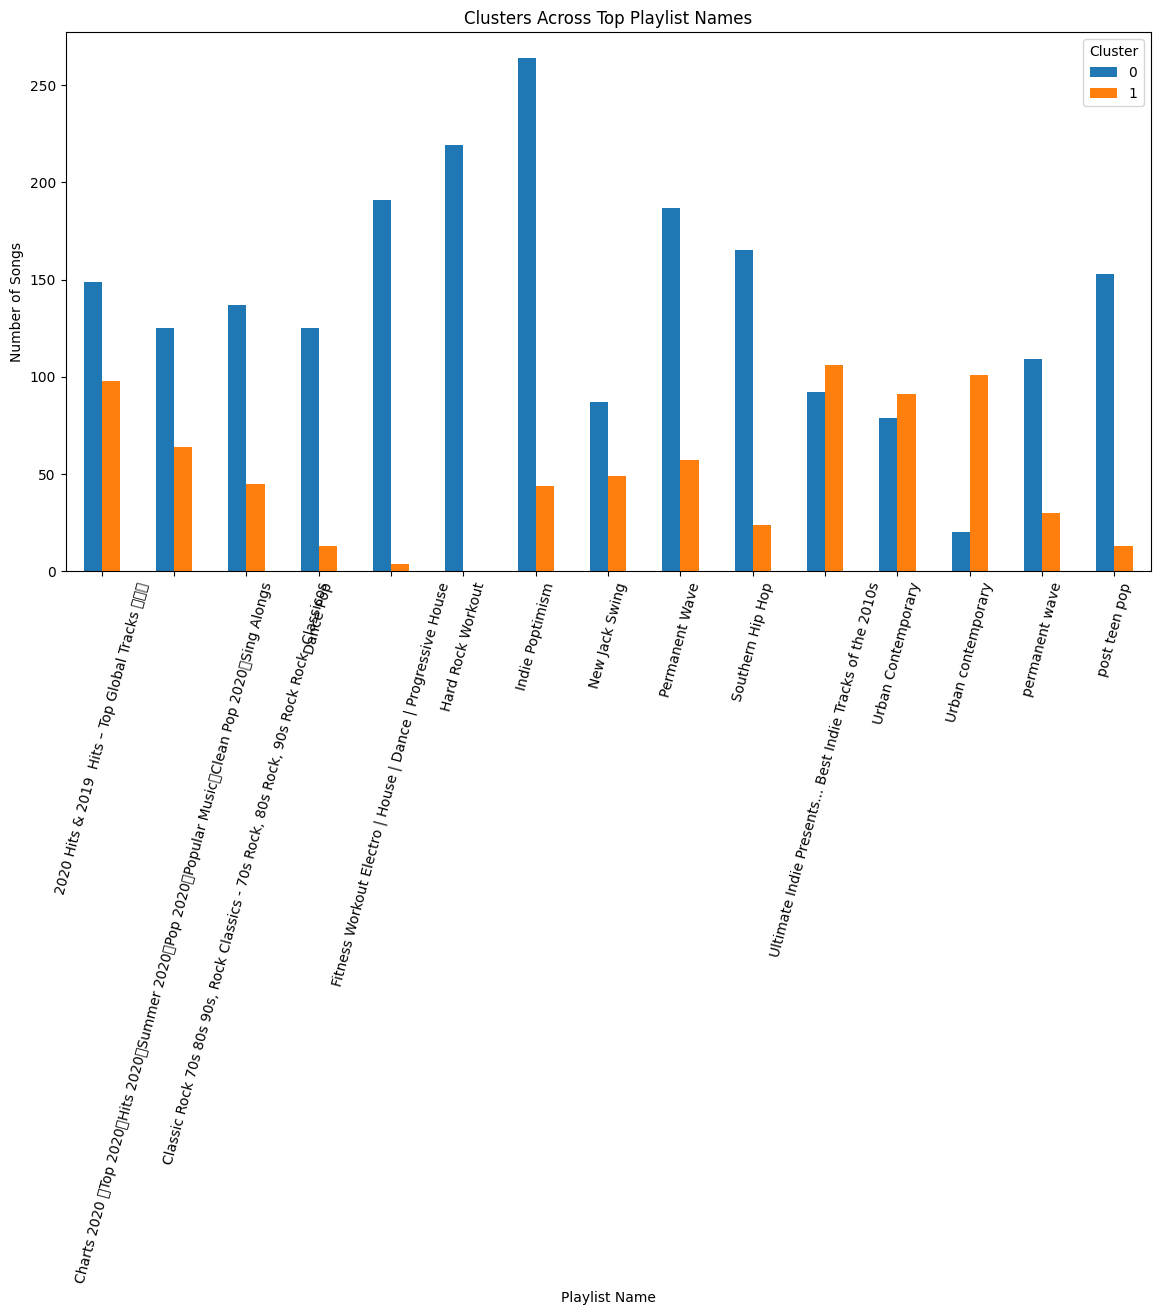

In [41]:
top_playlist_names = (
    df["playlist_name"]
    .value_counts()
    .head(15)
    .index
)

top_playlist_cluster = pd.crosstab(
    df[df["playlist_name"].isin(top_playlist_names)]["playlist_name"],
    df[df["playlist_name"].isin(top_playlist_names)]["cluster"]
)

top_playlist_cluster.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Clusters Across Top Playlist Names")
plt.xlabel("Playlist Name")
plt.ylabel("Number of Songs")
plt.xticks(rotation=75)
plt.legend(title="Cluster")
plt.show()

In [42]:
def recommend_songs(song_name, n=10):

    matches = df[
        df["track_name"].str.contains(
            song_name,
            case=False,
            na=False
        )
    ]

    if matches.empty:
        print("Song not found!")
        return

    song = matches.iloc[0]
    selected_cluster = song["cluster"]

    recommendations = df[
        (df["cluster"] == selected_cluster) &
        (df["track_name"] != song["track_name"])
    ]

    recommendations = recommendations.sort_values(
        "track_popularity",
        ascending=False
    ).head(n)

    print("Selected Song:", song["track_name"])
    print("Artist:", song["track_artist"])
    print("Cluster:", selected_cluster)

    return recommendations[
        [
            "track_name",
            "track_artist",
            "playlist_genre",
            "playlist_subgenre",
            "track_popularity",
            "cluster"
        ]
    ]

In [44]:
recommend_songs("Memories", 10)

Selected Song: Memories - Dillon Francis Remix
Artist: Maroon 5
Cluster: 0


,track_name,track_artist,playlist_genre,playlist_subgenre,track_popularity,cluster
21468,ROXANNE,Arizona Zervas,r&b,urban contemporary,99,0
20092,ROXANNE,Arizona Zervas,latin,latin hip hop,99,0
30202,ROXANNE,Arizona Zervas,edm,pop edm,99,0
23104,ROXANNE,Arizona Zervas,r&b,hip pop,99,0
21384,The Box,Roddy Ricch,r&b,urban contemporary,98,0
687,Tusa,KAROL G,pop,dance pop,98,0
716,Blinding Lights,The Weeknd,pop,dance pop,98,0
1605,Blinding Lights,The Weeknd,pop,post-teen pop,98,0
18756,Tusa,KAROL G,latin,reggaeton,98,0
23103,Tusa,KAROL G,r&b,hip pop,98,0


In [43]:
recommend_songs(df["track_name"].iloc[0], 10)

Song not found!


/tmp/ipykernel_691/1682019251.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["track_name"].str.contains(


In [45]:
final_silhouette = silhouette_score(
    X_scaled,
    df["cluster"]
)

print("===================================")
print("FINAL MODEL RESULT")
print("===================================")
print("Model: K-Means Clustering")
print("Number of Clusters:", best_k)
print("Silhouette Score:", round(final_silhouette, 4))
print("Number of Songs:", len(df))
print("Number of Genres:", df["playlist_genre"].nunique())
print("Number of Playlists:", df["playlist_name"].nunique())
print("===================================")

FINAL MODEL RESULT
Model: K-Means Clustering
Number of Clusters: 2
Silhouette Score: 0.1885
Number of Songs: 32833
Number of Genres: 6
Number of Playlists: 449


In [46]:
df.to_csv(
    "spotify_clustered_results.csv",
    index=False
)

print("Final clustered dataset saved successfully!")

Final clustered dataset saved successfully!


In [48]:
from google.colab import files

files.download("spotify_clustered_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>